In [ ]:
from google.colab import files

# Upload the zip file
uploaded = files.upload()


Saving ASB_clean (2).zip to ASB_clean (2).zip


In [ ]:
import zipfile

# Assuming 'folder_name.zip' is the uploaded file
with zipfile.ZipFile('ASB_clean (2).zip', 'r') as zip_ref:
    zip_ref.extractall('/ASB_clean/')


In [ ]:
import os

# List files in the current directory

fatigue_dir_training=os.path.join('/ASB_clean/ASB_clean/fatigue/training fatigue')
fatigue_dir_val= os.path.join('/ASB_clean/ASB_clean/fatigue/val fatigue')
non_fatigue_dir_training= os.path.join('/ASB_clean/ASB_clean/non fatigue/training non fatigue')
non_fatigue_dir_val= os.path.join('/ASB_clean/ASB_clean/non fatigue/val non fatigue')

In [ ]:
print('Total training fatigue data:', len(os.listdir(fatigue_dir_training)))
print('Total validation fatigue data:', len(os.listdir(fatigue_dir_val)))
print('Total training non fatigue data:', len(os.listdir(non_fatigue_dir_training)))
print('Total validation non fatigue data:', len(os.listdir(non_fatigue_dir_val)))

Total training fatigue data: 18
Total validation fatigue data: 4
Total training non fatigue data: 18
Total validation non fatigue data: 4


In [ ]:
import os #preprocessing semua file sekaligus dalam satu folder training fatigue
import pandas as pd

# Mendefinisikan folder yang mau diproses dan folder tempat hasil akan disimpan
directory = fatigue_dir_training
output_directory = 'content/ASB_after_prepro/fatigue/training fatigue'
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

# Iterasi untuk semua file dalam folder
for filename in os.listdir(directory):
    if filename.endswith('.csv'):  # Hanya CSV file yang diproses
        filepath = os.path.join(directory, filename)

        # Membaca CSV
        df = pd.read_csv(filepath)

        # Ekstrak kolom amplitudo
        amplitude = df['amplitudo']

        # Menghitung baseline
        baseline = amplitude.mean()

        # Mengurangi sinyal dengan baseline
        zeroed_amplitude = amplitude - baseline

        absolute_amplitude = zeroed_amplitude.abs()

        # Menggantikan nilai pada kolom amplitudo dengan nilai yang baru hasil proses
        df['amplitudo'] = absolute_amplitude

        # Menentukan detik awal dan akhir segmentasi
        start_time_seconds_1 = 16
        end_time_seconds_1 = 21

        # Konversi detik ke indeks sampel
        sampling_rate = 1000
        start_index_1 = start_time_seconds_1 * sampling_rate
        end_index_1 = end_time_seconds_1 * sampling_rate

        # Memotong sinyal EMG menjadi segmentasi yang diinginkan
        segmented_emg_1 = df.iloc[start_index_1:end_index_1]

        #segment kedua
        start_time_seconds_2 = 30  # Detik awal segmentasi kedua
        end_time_seconds_2 = 35    # Detik akhir segmentasi kedua

        # Konversi detik ke indeks sampel untuk segmentasi kedua
        start_index_2 = start_time_seconds_2 * sampling_rate
        end_index_2 = end_time_seconds_2 * sampling_rate

        # Memotong sinyal EMG menjadi segmentasi kedua
        segmented_emg_2 = df.iloc[start_index_2:end_index_2]

        #hasil prepro dari semua file disimpen dalem folder output
        output_filename_segment_1 = os.path.join(output_directory, f'zeroed_absolute_segment1_{filename}')
        segmented_emg_1.to_csv(output_filename_segment_1, index=False)
        output_filename_segment_2 = os.path.join(output_directory, f'zeroed_absolute_segment2_{filename}')
        segmented_emg_2.to_csv(output_filename_segment_2, index=False)


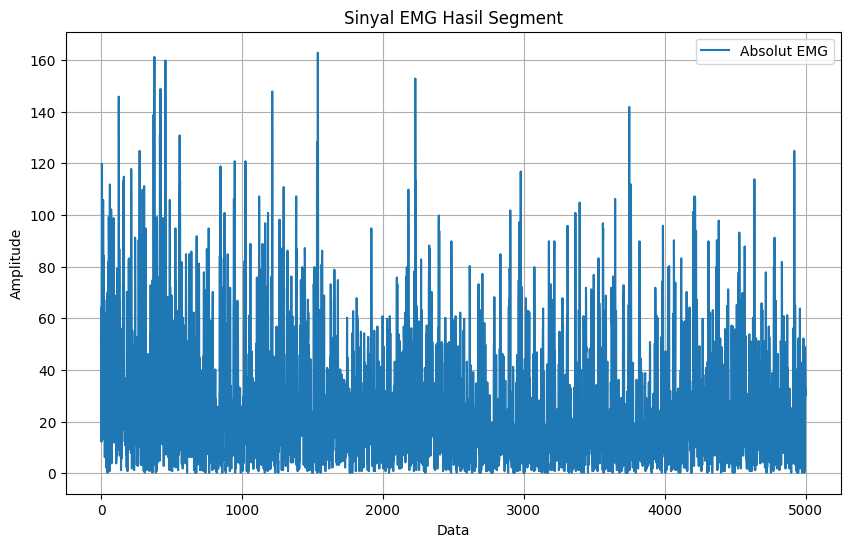

In [ ]:
import matplotlib.pyplot as plt #coba liat hasil preprocessing salah satu file

df = pd.read_csv('/content/content/ASB_after_prepro/fatigue/training fatigue/zeroed_absolute_segment1_Hasna_F.csv')
amplitude = df['amplitudo']
plt.figure(figsize=(10, 6))

plt.plot(amplitude, label='Absolut EMG')
plt.xlabel('Data')
plt.ylabel('Amplitude')
plt.title('Sinyal EMG Hasil Segment')
plt.legend()
plt.grid(True)
plt.show()

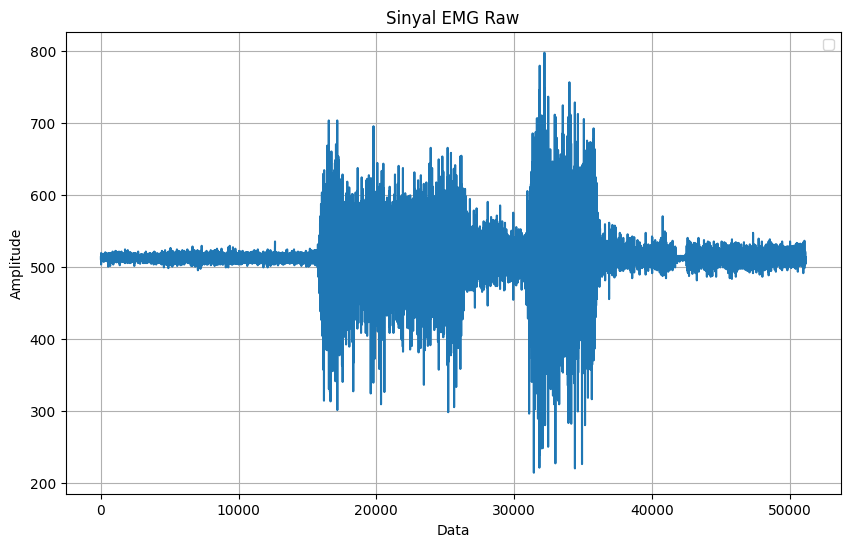

In [ ]:
import matplotlib.pyplot as plt #coba liat sinyal EMG raw

df = pd.read_csv('/content/Hasna_NF.csv')
amplitude = df['amplitudo']
plt.figure(figsize=(10, 6))

plt.plot(amplitude)
plt.xlabel('Data')
plt.ylabel('Amplitude')
plt.title('Sinyal EMG Raw')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import os #preprocessing semua file sekaligus dalam satu folder val fatigue
import pandas as pd

# Define the directory containing CSV files
directory = fatigue_dir_val
output_directory = 'content/ASB_after_prepro/fatigue/val fatigue'
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

# Iterate through each file in the directory
for filename in os.listdir(directory):
    if filename.endswith('.csv'):  # Process only CSV files
        filepath = os.path.join(directory, filename)

        # Read the CSV file into a DataFrame
        df = pd.read_csv(filepath)

        # Extract the amplitude column
        amplitude = df['amplitudo']

        # Calculate the baseline (e.g., mean or median of the signal)
        baseline = amplitude.mean()

        # Subtract the baseline from the entire signal
        zeroed_amplitude = amplitude - baseline

        absolute_amplitude = zeroed_amplitude.abs()

        # Replace the zeroed amplitude column in the DataFrame with the absolute values
        df['amplitudo'] = absolute_amplitude

        # Menentukan detik awal dan akhir segmentasi
        start_time_seconds_1 = 16
        end_time_seconds_1 = 21

        # Konversi detik ke indeks sampel
        sampling_rate = 1000
        start_index_1 = start_time_seconds_1 * sampling_rate
        end_index_1 = end_time_seconds_1 * sampling_rate

        # Memotong sinyal EMG menjadi segmentasi yang diinginkan
        segmented_emg_1 = df.iloc[start_index_1:end_index_1]

        #segment kedua
        start_time_seconds_2 = 30  # Detik awal segmentasi kedua
        end_time_seconds_2 = 35    # Detik akhir segmentasi kedua

        # Konversi detik ke indeks sampel untuk segmentasi kedua
        start_index_2 = start_time_seconds_2 * sampling_rate
        end_index_2 = end_time_seconds_2 * sampling_rate

        # Memotong sinyal EMG menjadi segmentasi kedua
        segmented_emg_2 = df.iloc[start_index_2:end_index_2]

        #hasil prepo dari semua file disimpen dalem folder output
        output_filename_segment_1 = os.path.join(output_directory, f'zeroed_absolute_segment1_{filename}')
        segmented_emg_1.to_csv(output_filename_segment_1, index=False)
        output_filename_segment_2 = os.path.join(output_directory, f'zeroed_absolute_segment2_{filename}')
        segmented_emg_2.to_csv(output_filename_segment_2, index=False)


In [ ]:
import os #preprocessing semua file sekaligus dalam satu folder val non fatigue
import pandas as pd

# Define the directory containing CSV files
directory = non_fatigue_dir_val
output_directory = 'content/ASB_after_prepro/non_fatigue/val non fatigue'
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

# Iterate through each file in the directory
for filename in os.listdir(directory):
    if filename.endswith('.csv'):  # Process only CSV files
        filepath = os.path.join(directory, filename)

        # Read the CSV file into a DataFrame
        df = pd.read_csv(filepath)

        # Extract the amplitude column
        amplitude = df['amplitudo']

        # Calculate the baseline (e.g., mean or median of the signal)
        baseline = amplitude.mean()

        # Subtract the baseline from the entire signal
        zeroed_amplitude = amplitude - baseline

        absolute_amplitude = zeroed_amplitude.abs()

        # Replace the zeroed amplitude column in the DataFrame with the absolute values
        df['amplitudo'] = absolute_amplitude

        # Menentukan detik awal dan akhir segmentasi
        start_time_seconds_1 = 16
        end_time_seconds_1 = 21

        # Konversi detik ke indeks sampel
        sampling_rate = 1000
        start_index_1 = start_time_seconds_1 * sampling_rate
        end_index_1 = end_time_seconds_1 * sampling_rate

        # Memotong sinyal EMG menjadi segmentasi yang diinginkan
        segmented_emg_1 = df.iloc[start_index_1:end_index_1]

        #segment kedua
        start_time_seconds_2 = 30  # Detik awal segmentasi kedua
        end_time_seconds_2 = 35    # Detik akhir segmentasi kedua

        # Konversi detik ke indeks sampel untuk segmentasi kedua
        start_index_2 = start_time_seconds_2 * sampling_rate
        end_index_2 = end_time_seconds_2 * sampling_rate

        # Memotong sinyal EMG menjadi segmentasi kedua
        segmented_emg_2 = df.iloc[start_index_2:end_index_2]

        #hasil prepo dari semua file disimpen dalem folder output
        output_filename_segment_1 = os.path.join(output_directory, f'zeroed_absolute_segment1_{filename}')
        segmented_emg_1.to_csv(output_filename_segment_1, index=False)
        output_filename_segment_2 = os.path.join(output_directory, f'zeroed_absolute_segment2_{filename}')
        segmented_emg_2.to_csv(output_filename_segment_2, index=False)


In [ ]:
import os #preprocessing semua file sekaligus dalam satu folder training non fatigue
import pandas as pd

# Define the directory containing CSV files
directory = non_fatigue_dir_training
output_directory = 'content/ASB_after_prepro/non_fatigue/training non fatigue'
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

# Iterate through each file in the directory
for filename in os.listdir(directory):
    if filename.endswith('.csv'):  # Process only CSV files
        filepath = os.path.join(directory, filename)

        # Read the CSV file into a DataFrame
        df = pd.read_csv(filepath)

        # Extract the amplitude column
        amplitude = df['amplitudo']

        # Calculate the baseline (e.g., mean or median of the signal)
        baseline = amplitude.mean()

        # Subtract the baseline from the entire signal
        zeroed_amplitude = amplitude - baseline

        absolute_amplitude = zeroed_amplitude.abs()

        # Replace the zeroed amplitude column in the DataFrame with the absolute values
        df['amplitudo'] = absolute_amplitude

        # Menentukan detik awal dan akhir segmentasi
        start_time_seconds_1 = 16
        end_time_seconds_1 = 21

        # Konversi detik ke indeks sampel
        sampling_rate = 1000
        start_index_1 = start_time_seconds_1 * sampling_rate
        end_index_1 = end_time_seconds_1 * sampling_rate

        # Memotong sinyal EMG menjadi segmentasi yang diinginkan
        segmented_emg_1 = df.iloc[start_index_1:end_index_1]

        #segment kedua
        start_time_seconds_2 = 30  # Detik awal segmentasi kedua
        end_time_seconds_2 = 35    # Detik akhir segmentasi kedua

        # Konversi detik ke indeks sampel untuk segmentasi kedua
        start_index_2 = start_time_seconds_2 * sampling_rate
        end_index_2 = end_time_seconds_2 * sampling_rate

        # Memotong sinyal EMG menjadi segmentasi kedua
        segmented_emg_2 = df.iloc[start_index_2:end_index_2]

        #hasil prepo dari semua file disimpen dalem folder output

        output_filename_segment_1 = os.path.join(output_directory, f'zeroed_absolute_segment1_{filename}')
        segmented_emg_1.to_csv(output_filename_segment_1, index=False)
        output_filename_segment_2 = os.path.join(output_directory, f'zeroed_absolute_segment2_{filename}')
        segmented_emg_2.to_csv(output_filename_segment_2, index=False)


In [ ]:
import shutil
import os

# Path folder yang akan didownload
folder_path = '/content/content/ASB_after_prepro'

# Path untuk file zip yang akan dibuat
zip_file_path = '/content/content/ASB_after_prepro.zip'

# Kompresi folder menjadi file zip
shutil.make_archive(zip_file_path, 'zip', folder_path)

"""
# Kemudian kirimkan file zip tersebut sebagai respons HTTP
# Contoh menggunakan modul Flask:
from flask import Flask, send_file

app = Flask(__name__)

@app.route('/download')
def download_folder():
    return send_file(zip_file_path, as_attachment=True)

if __name__ == '__main__':
    app.run()"""

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


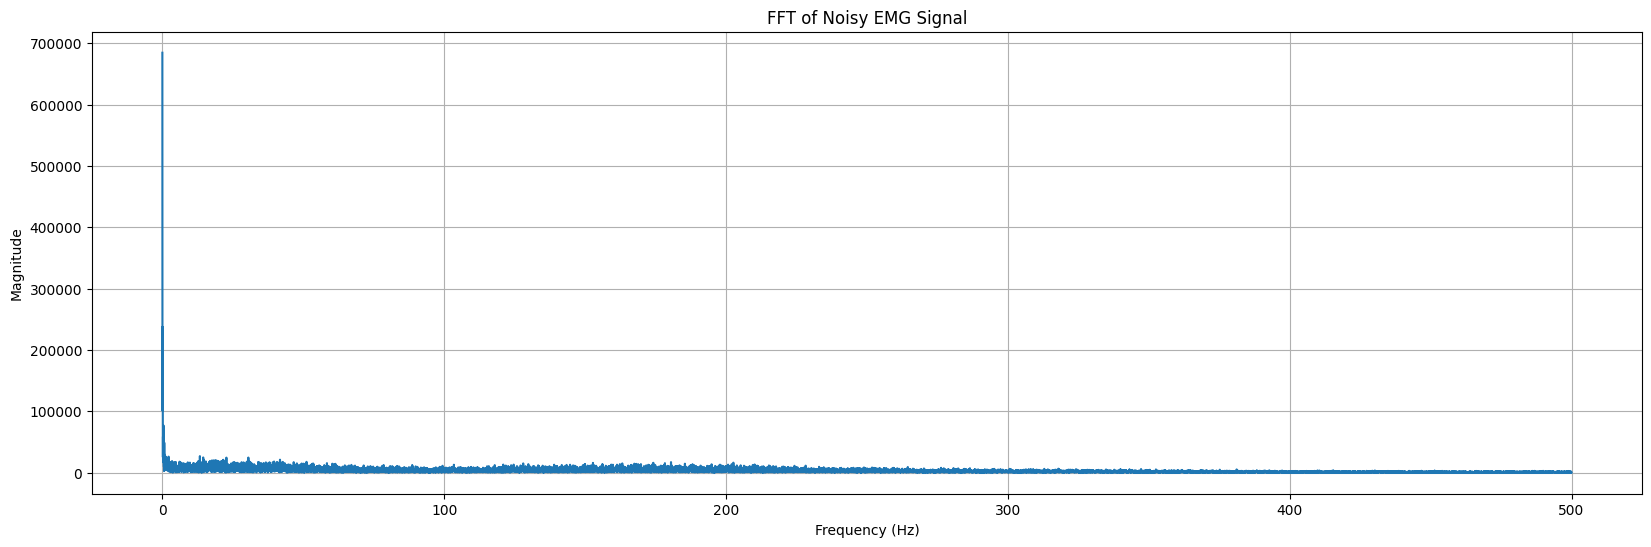

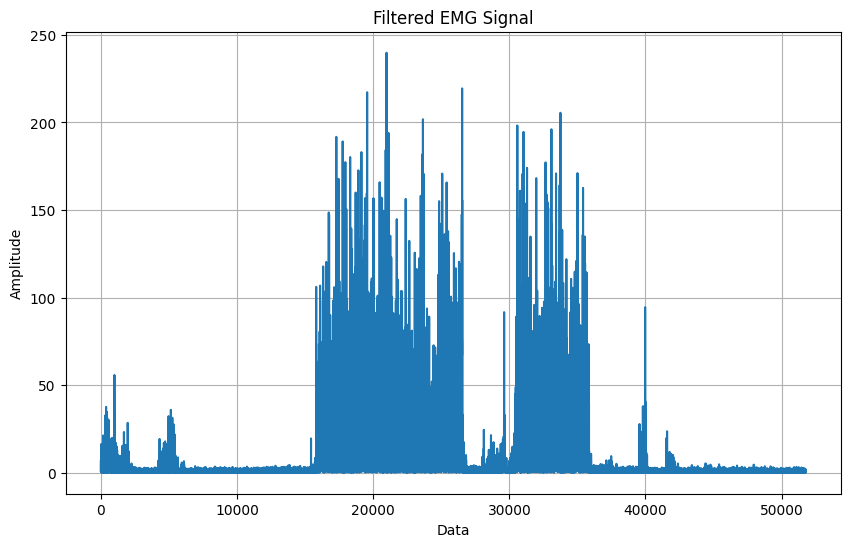

In [ ]:
import numpy as np #nyoba fft
sampling_rate = 1000
fft_result = np.fft.fft(amplitude)
freqs = np.fft.fftfreq(len(amplitude), 1/sampling_rate)

# Plot FFT result (magnitude)
plt.figure(figsize=(20, 6))
plt.plot(freqs[:len(freqs)//2], np.abs(fft_result)[:len(freqs)//2])  # Plot only positive frequencies
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('FFT of Noisy EMG Signal')
plt.grid(True)
plt.show()

# Filter the FFT result
cutoff_frequency = 30
fft_result_filtered = fft_result.copy()
fft_result_filtered[np.abs(freqs) < cutoff_frequency] = 0

# Perform inverse FFT
filtered_signal = np.fft.ifft(fft_result_filtered)
baseline = filtered_signal.mean()

# Subtract the baseline from the entire signal
zeroed_amplitude = filtered_signal - baseline

absolute_amplitude = np.abs(zeroed_amplitude)

# Replace the zeroed amplitude column in the DataFrame with the absolute value
df['amplitudo'] = absolute_amplitude
# Plot the filtered signal
plt.figure(figsize=(10, 6))
plt.plot(absolute_amplitude)  # Take real part since there might be small imaginary components due to numerical errors
plt.xlabel('Data')
plt.ylabel('Amplitude')
plt.title('Filtered EMG Signal')
plt.grid(True)
plt.show()

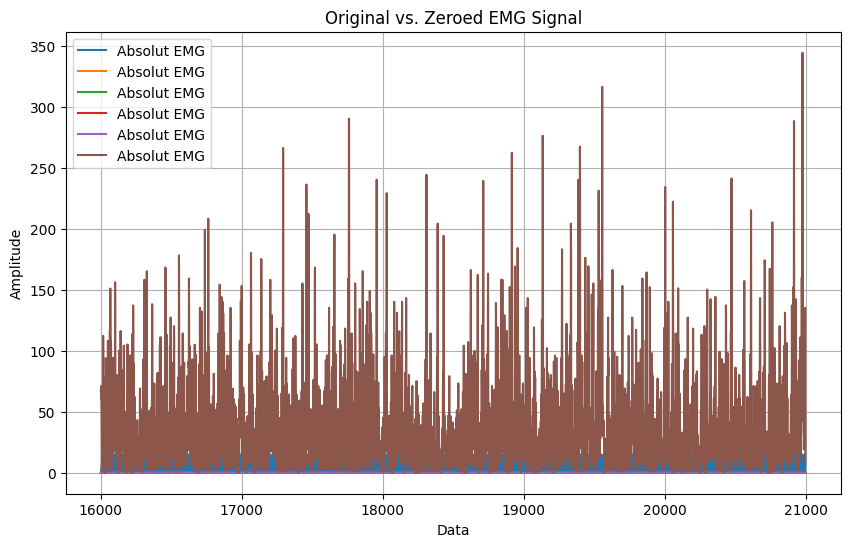

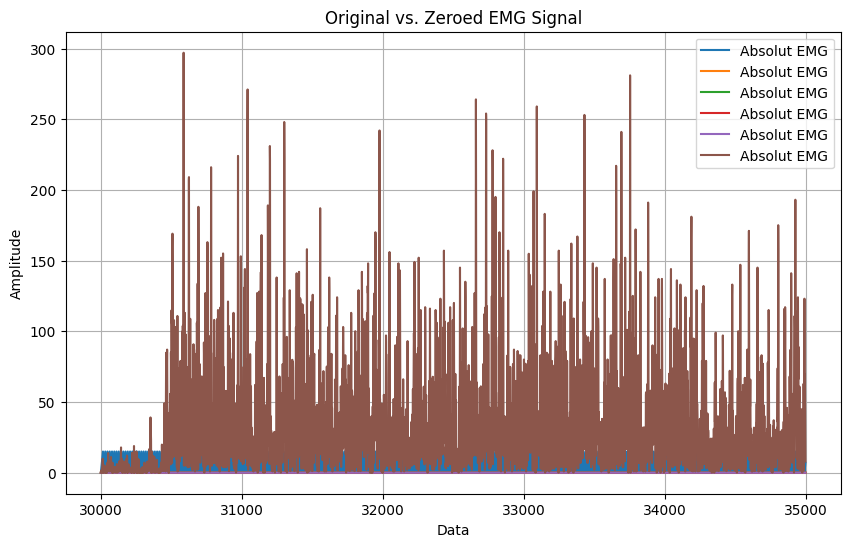

In [ ]:
#nyoba segment salah satu file

# Menentukan detik awal dan akhir segmentasi
start_time_seconds_1 = 16
end_time_seconds_1 = 21

# Konversi detik ke indeks sampel
sampling_rate = 1000
start_index_1 = start_time_seconds_1 * sampling_rate
end_index_1 = end_time_seconds_1 * sampling_rate

# Memotong sinyal EMG menjadi segmentasi yang diinginkan
segmented_emg_1 = df.iloc[start_index_1:end_index_1]

#segment kedua
start_time_seconds_2 = 30  # Detik awal segmentasi kedua
end_time_seconds_2 = 35    # Detik akhir segmentasi kedua

# Konversi detik ke indeks sampel untuk segmentasi kedua
start_index_2 = start_time_seconds_2 * sampling_rate
end_index_2 = end_time_seconds_2 * sampling_rate

# Memotong sinyal EMG menjadi segmentasi kedua
segmented_emg_2 = df.iloc[start_index_2:end_index_2]



plt.figure(figsize=(10, 6))
#plt.plot(original_amplitude, label='Original EMG')
plt.plot(segmented_emg_1, label='Absolut EMG')
plt.xlabel('Data')
plt.ylabel('Amplitude')
plt.title('Original vs. Zeroed EMG Signal')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
#plt.plot(original_amplitude, label='Original EMG')
plt.plot(segmented_emg_2, label='Absolut EMG')
plt.xlabel('Data')
plt.ylabel('Amplitude')
plt.title('Original vs. Zeroed EMG Signal')
plt.legend()
plt.grid(True)
plt.show()

## Prepro data test

In [ ]:
from google.colab import files

# Upload the zip file
uploaded = files.upload()


Saving ASB_test.zip to ASB_test.zip


In [ ]:
import zipfile

# Assuming 'folder_name.zip' is the uploaded file
with zipfile.ZipFile('ASB_test.zip', 'r') as zip_ref:
    zip_ref.extractall('/ASB_test/')


In [ ]:
import os

# List files in the current directory

fatigue_dir_test=os.path.join('/ASB_test/ASB_test/fatigue')
non_fatigue_dir_test= os.path.join('/ASB_test/ASB_test/non fatigue')

In [ ]:
print('Total testing fatigue data:', len(os.listdir(fatigue_dir_test)))
print('Total testing non fatigue data:', len(os.listdir(non_fatigue_dir_test)))

Total testing fatigue data: 4
Total testing non fatigue data: 4


In [ ]:
import os #preprocessing semua file sekaligus dalam satu folder testing fatigue
import pandas as pd

# Define the directory containing CSV files
directory = fatigue_dir_test
output_directory = 'content/ASB_test_after_prepro/fatigue'
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

# Iterate through each file in the directory
for filename in os.listdir(directory):
    if filename.endswith('.csv'):  # Process only CSV files
        filepath = os.path.join(directory, filename)

        # Read the CSV file into a DataFrame
        df = pd.read_csv(filepath)

        # Extract the amplitude column
        amplitude = df['amplitudo']

        # Calculate the baseline (e.g., mean or median of the signal)
        baseline = amplitude.mean()

        # Subtract the baseline from the entire signal
        zeroed_amplitude = amplitude - baseline

        absolute_amplitude = zeroed_amplitude.abs()

        # Replace the zeroed amplitude column in the DataFrame with the absolute values
        df['amplitudo'] = absolute_amplitude

        # Menentukan detik awal dan akhir segmentasi
        start_time_seconds_1 = 16
        end_time_seconds_1 = 21

        # Konversi detik ke indeks sampel
        sampling_rate = 1000
        start_index_1 = start_time_seconds_1 * sampling_rate
        end_index_1 = end_time_seconds_1 * sampling_rate

        # Memotong sinyal EMG menjadi segmentasi yang diinginkan
        segmented_emg_1 = df.iloc[start_index_1:end_index_1]

        #segment kedua
        start_time_seconds_2 = 30  # Detik awal segmentasi kedua
        end_time_seconds_2 = 35    # Detik akhir segmentasi kedua

        # Konversi detik ke indeks sampel untuk segmentasi kedua
        start_index_2 = start_time_seconds_2 * sampling_rate
        end_index_2 = end_time_seconds_2 * sampling_rate

        # Memotong sinyal EMG menjadi segmentasi kedua
        segmented_emg_2 = df.iloc[start_index_2:end_index_2]

        #hasil prepo dari semua file disimpen dalem folder output
        output_filename_segment_1 = os.path.join(output_directory, f'zeroed_absolute_segment1_{filename}')
        segmented_emg_1.to_csv(output_filename_segment_1, index=False)
        output_filename_segment_2 = os.path.join(output_directory, f'zeroed_absolute_segment2_{filename}')
        segmented_emg_2.to_csv(output_filename_segment_2, index=False)


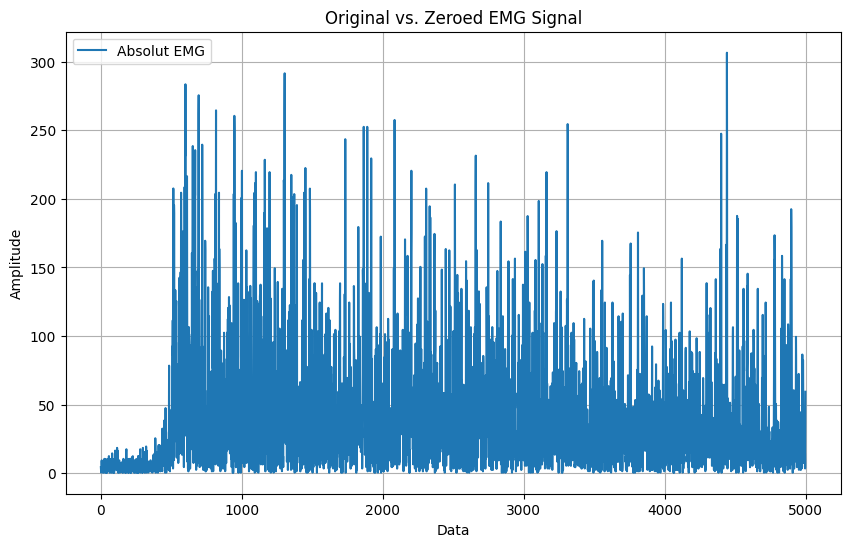

In [ ]:
import matplotlib.pyplot as plt #coba liat hasil preprocessing salah satu file

df = pd.read_csv('/content/content/ASB_test_after_prepro/fatigue/zeroed_absolute_segment2_tarisa_f.csv')
amplitude = df['amplitudo']
plt.figure(figsize=(10, 6))
#plt.plot(original_amplitude, label='Original EMG')
plt.plot(amplitude, label='Absolut EMG')
plt.xlabel('Data')
plt.ylabel('Amplitude')
plt.title('Original vs. Zeroed EMG Signal')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import os #preprocessing semua file sekaligus dalam satu folder testing non fatigue
import pandas as pd

# Define the directory containing CSV files
directory = non_fatigue_dir_test
output_directory = 'content/ASB_test_after_prepro/non fatigue'
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

# Iterate through each file in the directory
for filename in os.listdir(directory):
    if filename.endswith('.csv'):  # Process only CSV files
        filepath = os.path.join(directory, filename)

        # Read the CSV file into a DataFrame
        df = pd.read_csv(filepath)

        # Extract the amplitude column
        amplitude = df['amplitudo']

        # Calculate the baseline (e.g., mean or median of the signal)
        baseline = amplitude.mean()

        # Subtract the baseline from the entire signal
        zeroed_amplitude = amplitude - baseline

        absolute_amplitude = zeroed_amplitude.abs()

        # Replace the zeroed amplitude column in the DataFrame with the absolute values
        df['amplitudo'] = absolute_amplitude

        # Menentukan detik awal dan akhir segmentasi
        start_time_seconds_1 = 16
        end_time_seconds_1 = 21

        # Konversi detik ke indeks sampel
        sampling_rate = 1000
        start_index_1 = start_time_seconds_1 * sampling_rate
        end_index_1 = end_time_seconds_1 * sampling_rate

        # Memotong sinyal EMG menjadi segmentasi yang diinginkan
        segmented_emg_1 = df.iloc[start_index_1:end_index_1]

        #segment kedua
        start_time_seconds_2 = 30  # Detik awal segmentasi kedua
        end_time_seconds_2 = 35    # Detik akhir segmentasi kedua

        # Konversi detik ke indeks sampel untuk segmentasi kedua
        start_index_2 = start_time_seconds_2 * sampling_rate
        end_index_2 = end_time_seconds_2 * sampling_rate

        # Memotong sinyal EMG menjadi segmentasi kedua
        segmented_emg_2 = df.iloc[start_index_2:end_index_2]

        #hasil prepo dari semua file disimpen dalem folder output
        output_filename_segment_1 = os.path.join(output_directory, f'zeroed_absolute_segment1_{filename}')
        segmented_emg_1.to_csv(output_filename_segment_1, index=False)
        output_filename_segment_2 = os.path.join(output_directory, f'zeroed_absolute_segment2_{filename}')
        segmented_emg_2.to_csv(output_filename_segment_2, index=False)


In [ ]:
import shutil
import os

# Path folder yang akan didownload
folder_path = '/content/content/ASB_test_after_prepro'

# Path untuk file zip yang akan dibuat
zip_file_path = '/content/content/ASB_test_after_prepro.zip'

# Kompresi folder menjadi file zip
shutil.make_archive(zip_file_path, 'zip', folder_path)


'/content/content/ASB_test_after_prepro.zip.zip'

## Nyoba 1 file untuk ekstraksi fitur

In [ ]:
"""import pandas as pd
df = pd.read_csv('azka_F.csv')

# Extract the amplitude column
amplitude = df['amplitudo']

# Calculate the baseline (e.g., mean or median of the signal)
baseline = amplitude.mean()  # You can use .mean() or .median() based on your preference

# Subtract the baseline from the entire signal
zeroed_amplitude = amplitude - baseline

# Replace the Amplitude column in the DataFrame with the zeroed amplitude
#df['amplitudo'] = zeroed_amplitude

absolute_amplitude = zeroed_amplitude.abs()

# Replace the zeroed amplitude column in the DataFrame with the absolute value
df['amplitudo'] = absolute_amplitude  # Replace with correct column name

# Save the modified DataFrame back to a CSV file
#output_filename = os.path.join(directory, f'zeroed_absolute_{filename}')
#df.to_csv('hasil_emg.csv', index=False)

#nyoba satu file"""

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Function to calculate RMS values using windowing
def calculate_rms_with_windowing(signal, window_size, overlap):
    rms_values = []
    start = 0

    while start + window_size <= len(signal):
        window = signal[start:start+window_size]
        rms = np.sqrt(np.mean(np.square(window)))
        rms_values.append(rms)
        start += window_size - overlap

    return rms_values


def calculate_mav_with_windowing(signal, window_size, overlap):
    mav_values = []
    start = 0

    while start + window_size <= len(signal):
        window = signal[start:start+window_size]
        mav = np.mean(np.abs(window))
        mav_values.append(mav)
        start += window_size - overlap

    return mav_values

def calculate_var_with_windowing(signal, window_size, overlap):
    var_values = []
    start = 0

    while start + window_size <= len(signal):
        window = signal[start:start+window_size]
        var = np.var(window)
        var_values.append(var)
        start += window_size - overlap

    return var_values

df = pd.read_csv('azka_F.csv')

# Extract the amplitude column
amplitude = df['amplitudo']

# Calculate the baseline (e.g., mean or median of the signal)
baseline = amplitude.mean()  # You can use .mean() or .median() based on your preference

# Subtract the baseline from the entire signal
zeroed_amplitude = amplitude - baseline

# Replace the Amplitude column in the DataFrame with the zeroed amplitude
#df['amplitudo'] = zeroed_amplitude

absolute_amplitude = zeroed_amplitude.abs()
df['amplitudo'] = absolute_amplitude


start_time_seconds_1 = 16
end_time_seconds_1 = 21

# Konversi detik ke indeks sampel
sampling_rate = 1000
start_index_1 = start_time_seconds_1 * sampling_rate
end_index_1 = end_time_seconds_1 * sampling_rate

# Memotong sinyal EMG menjadi segmentasi yang diinginkan
segmented_emg_1 = df.iloc[start_index_1:end_index_1]

window_size = 100  # Define the size of the window
overlap = 50  # Define the overlap between windows

rms_values = calculate_rms_with_windowing(segmented_emg_1, window_size, overlap)
rms_array = np.array(rms_values)
rms_array = rms_array.reshape(99,1)

mav_values = calculate_mav_with_windowing(segmented_emg_1, window_size, overlap)
mav_array = np.array(mav_values)
mav_array = mav_array.reshape(99,1)

var_values = calculate_var_with_windowing(segmented_emg_1, window_size, overlap)
df = pd.DataFrame(var_values)
amp_var_values = df.loc[:, 'amplitudo']
var_array = np.array(amp_var_values)
var_array = var_array.reshape(99,1)

emg_after = np.stack([rms_array, mav_array, var_array])
emg_after_flat = emg_after.reshape(emg_after.shape[0], -1)
np.savetxt('emg_after.csv', emg_after_flat, delimiter=',')

#print(emg_after)
print("Shape:", emg_after_flat.shape)
"""output_directory = 'content/ASB_test_after_prepro/'
output_filename = os.path.join(output_directory, f'hasil ekstraksi fitur_')
emg_after.to_csv(output_filename, index=False)
#matrix_3d = np.stack([matrix1, matrix2, matrix3])"""
"""# Plot RMS values
plt.figure(figsize=(10, 6))
plt.plot(rms_values, label='RMS values')
plt.xlabel('Window Index')
plt.ylabel('RMS Value')
plt.title('RMS Values of EMG Signal with Windowing')
plt.legend()
plt.grid(True)
plt.show()


# Plot MAV values
plt.figure(figsize=(10, 6))
plt.plot(mav_values, label='MAV values')
plt.xlabel('Window Index')
plt.ylabel('MAV Value')
plt.title('MAV Values of EMG Signal with Windowing')
plt.legend()
plt.grid(True)
plt.show()


# Plot VAR values
plt.figure(figsize=(10, 6))
plt.plot(amp_var_values) #, label='VAR values')
plt.xlabel('Window Index')
plt.ylabel('VAR Value')
plt.title('VAR Values of EMG Signal with Windowing')
plt.legend()
plt.grid(True)
plt.show()"""


#print(var_values)
# Save the modified DataFrame back to a CSV file
#output_filename = os.path.join(directory, f'zeroed_absolute_{filename}')
#df.to_csv('hasil_emg.csv', index=False)

#nyoba satu file

Shape: (3, 99)


"# Plot RMS values\nplt.figure(figsize=(10, 6))\nplt.plot(rms_values, label='RMS values')\nplt.xlabel('Window Index')\nplt.ylabel('RMS Value')\nplt.title('RMS Values of EMG Signal with Windowing')\nplt.legend()\nplt.grid(True)\nplt.show()\n\n\n# Plot MAV values\nplt.figure(figsize=(10, 6))\nplt.plot(mav_values, label='MAV values')\nplt.xlabel('Window Index')\nplt.ylabel('MAV Value')\nplt.title('MAV Values of EMG Signal with Windowing')\nplt.legend()\nplt.grid(True)\nplt.show()\n\n\n# Plot VAR values\nplt.figure(figsize=(10, 6))\nplt.plot(amp_var_values) #, label='VAR values')\nplt.xlabel('Window Index')\nplt.ylabel('VAR Value')\nplt.title('VAR Values of EMG Signal with Windowing')\nplt.legend()\nplt.grid(True)\nplt.show()"

In [ ]:
import numpy as np

# Fungsi untuk menghitung nilai VAR dengan windowing
def calculate_var_with_windowing(signal, window_size, overlap):
    var_values = []
    start = 0

    while start + window_size <= len(signal):
        window = signal[start:start+window_size]
        var = np.var(window)
        var_values.append(var)
        start += window_size - overlap

    return var_values

# Contoh data sinyal EMG (gantilah dengan data Anda sendiri)
emg_signal = np.random.rand(1000)  # Data sinyal EMG
window_size = 100  # Ukuran jendela
overlap = 50  # Overlap antarjendela

# Hitung nilai VAR dengan windowing
var_values = calculate_var_with_windowing(emg_signal, window_size, overlap)

# Tampilkan nilai VAR
print("Nilai VAR dari sinyal EMG:", var_values)


In [ ]:
import numpy as np

# Fungsi untuk menghitung nilai MAV dengan windowing
def calculate_mav_with_windowing(signal, window_size, overlap):
    mav_values = []
    start = 0

    while start + window_size <= len(signal):
        window = signal[start:start+window_size]
        mav = np.mean(np.abs(window))
        mav_values.append(mav)
        start += window_size - overlap

    return mav_values

# Contoh data sinyal EMG (gantilah dengan data Anda sendiri)
emg_signal = np.random.rand(1000)  # Data sinyal EMG
window_size = 100  # Ukuran jendela
overlap = 50  # Overlap antarjendela

# Hitung nilai MAV dengan windowing
mav_values = calculate_mav_with_windowing(emg_signal, window_size, overlap)

# Tampilkan nilai MAV
print("Nilai MAV dari sinyal EMG:", mav_values)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate RMS values using windowing
def calculate_rms_with_windowing(signal, window_size, overlap):
    rms_values = []
    start = 0

    while start + window_size <= len(signal):
        window = signal[start:start+window_size]
        rms = np.sqrt(np.mean(np.square(window)))
        rms_values.append(rms)
        start += window_size - overlap

    return rms_values

# Example parameters
window_size = 100  # Define the size of the window
overlap = 50  # Define the overlap between windows

# Example EMG signal data
emg_signal = np.random.rand(1000)  # Replace this with your actual EMG signal data

# Calculate RMS values with windowing
rms_values = calculate_rms_with_windowing(emg_signal, window_size, overlap)

# Plot RMS values
plt.figure(figsize=(10, 6))
plt.plot(rms_values, label='RMS values')
plt.xlabel('Window Index')
plt.ylabel('RMS Value')
plt.title('RMS Values of EMG Signal with Windowing')
plt.legend()
plt.grid(True)
plt.show()


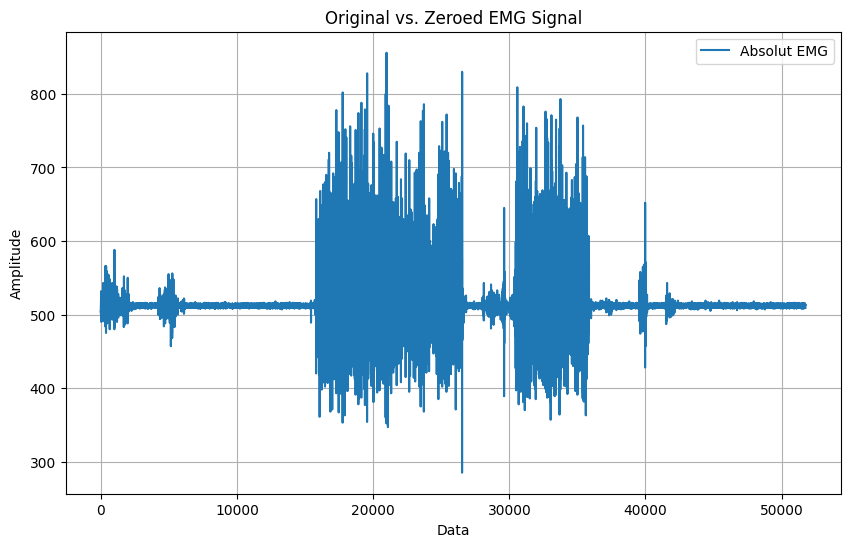

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('azka_F.csv')

# Extract the amplitude column
amplitude = df['amplitudo']


plt.figure(figsize=(10, 6))
#plt.plot(original_amplitude, label='Original EMG')
plt.plot(amplitude, label='Absolut EMG')
plt.xlabel('Data')
plt.ylabel('Amplitude')
plt.title('Original vs. Zeroed EMG Signal')
plt.legend()
plt.grid(True)
plt.show()


## Iterasi ekstraksi fitur untuk semua file

In [ ]:
from google.colab import files

# Upload the zip file
uploaded = files.upload()


Saving ASB_after_prepro_segment2only.zip to ASB_after_prepro_segment2only.zip


In [ ]:
import zipfile

# Assuming 'folder_name.zip' is the uploaded file
with zipfile.ZipFile('ASB_after_prepro_segment2only.zip', 'r') as zip_ref:
    zip_ref.extractall('/ASB_after_prepro_segment2only/')


In [ ]:
import os

# List files in the current directory

fatigue_dir_training=os.path.join('/ASB_after_prepro_segment2only/ASB_after_prepro (udah dipindah)/ASB_after_prepro/fatigue/training fatigue')
#fatigue_dir_val= os.path.join('/ASB_clean/ASB_clean/fatigue/val fatigue')
non_fatigue_dir_training= os.path.join('/ASB_after_prepro_segment2only/ASB_after_prepro (udah dipindah)/ASB_after_prepro/non_fatigue/training non fatigue')
#non_fatigue_dir_val= os.path.join('/ASB_clean/ASB_clean/non fatigue/val non fatigue')

In [ ]:
print('Total training fatigue data:', len(os.listdir(fatigue_dir_training)))
#print('Total validation fatigue data:', len(os.listdir(fatigue_dir_val)))
print('Total training non fatigue data:', len(os.listdir(non_fatigue_dir_training)))
#print('Total validation non fatigue data:', len(os.listdir(non_fatigue_dir_val)))

Total training fatigue data: 18
Total training non fatigue data: 18


In [ ]:
import os
import pandas as pd
import numpy as np

def windowing(signal, window_size, overlap):
    windows = []
    start = 0
    while start + window_size <= len(signal):
        window = signal[start:start+window_size]
        windows.append(window)
        start += window_size - overlap
    return windows
def calculate_rms(signal):
    return np.sqrt(np.mean(np.square(signal)))

def calculate_var(signal):
    return np.var(signal)

def calculate_mav(signal):
    return np.mean(np.abs(signal))

# Define the directory containing CSV files
directory = fatigue_dir_training # Replace with the path to your directory

# Iterate through each file in the directory
for filename in os.listdir(directory):
    if filename.endswith('.csv'):  # Process only CSV files
        filepath = os.path.join(directory, filename)

        # Read the CSV file into a DataFrame
        df = pd.read_csv(filepath)

        # Extract the amplitude column
        amplitude = df['amplitudo']

        window_size = 100  # Define the size of the window
        overlap = 50  # Define the overlap between windows

        # Perform windowing
        windows = windowing(amplitude, window_size, overlap)

        rms_values = []
        var_values = []
        mav_values = []

        # Calculate RMS, VAR, and MAV for each window
        for window in windows:
            rms_values.append(calculate_rms(window))
            var_values.append(calculate_var(window))
            mav_values.append(calculate_mav(window))

        # Create a DataFrame to display the results
        results_df = pd.DataFrame({
            'Window': [f'Window {i+1}' for i in range(len(windows))],
            'RMS': rms_values,
            'MAV': mav_values,
            'VAR': var_values
        })

        # Print the results for each file
        print(f'File: {filename}')
        print(results_df)
        print('')



File: zeroed_absolute_segment2_aida_F.h5.h5.csv
       Window         RMS         MAV           VAR
0    Window 1    1.965208    1.513952      1.569993
1    Window 2    1.791516    1.341317      1.410396
2    Window 3    2.303189    1.704611      2.398980
3    Window 4    3.046104    2.377246      3.627453
4    Window 5    2.878010    2.283952      3.066504
..        ...         ...         ...           ...
94  Window 95  126.381383   88.486706   8142.356629
95  Window 96  165.431696  115.324072  14068.004430
96  Window 97  142.267919   93.100778  11572.405826
97  Window 98   91.778226   58.952096   4947.893144
98  Window 99   94.424596   69.347485   4106.930683

[99 rows x 4 columns]

File: zeroed_absolute_segment2_caca_f.csv
       Window        RMS        MAV          VAR
0    Window 1   3.988777   3.035057     6.698771
1    Window 2   3.513987   2.512586     6.035013
2    Window 3   4.754002   3.335057    11.477927
3    Window 4   4.705652   3.367567    10.802652
4    Window 5   5

In [ ]:
directory = fatigue_dir_training

"""rms_values_list = []
mav_values_list = []
var_values_list = []"""
matrices = []
cek_window =[]
#output_directory = 'content/ASB_test_after_prepro/non fatigue'
#if not os.path.exists(output_directory):
#    os.makedirs(output_directory)

# Iterate through each file in the directory
for filename in os.listdir(directory):
    if filename.endswith('.csv'):
      start=0
      window_size = 100
      overlap = 50
      while start + window_size <= len(signal):
        window = signal[start:start+window_size]
        cek_window.append(window)
        start += window_size - overlap


In [ ]:
import os #preprocessing semua file sekaligus dalam satu folder testing non fatigue
import pandas as pd
import numpy as np

def calculate_rms_with_windowing(signal, window_size, overlap):
    rms_values = []
    start = 0

    while start + window_size <= len(signal):
        window = signal[start:start+window_size]
        rms = np.sqrt(np.mean(np.square(window)))
        rms_values.append(rms)
        start += window_size - overlap

    return rms_values


def calculate_mav_with_windowing(signal, window_size, overlap):
    mav_values = []
    start = 0

    while start + window_size <= len(signal):
        window = signal[start:start+window_size]
        mav = np.mean(np.abs(window))
        mav_values.append(mav)
        start += window_size - overlap

    return mav_values

def calculate_var_with_windowing(signal, window_size, overlap):
    var_values = []
    start = 0

    while start + window_size <= len(signal):
        window = signal[start:start+window_size]
        var = np.var(window)
        var_values.append(var)
        start += window_size - overlap

    return var_values

# Define the directory containing CSV files
directory = fatigue_dir_training

"""rms_values_list = []
mav_values_list = []
var_values_list = []"""
matrices = []
#output_directory = 'content/ASB_test_after_prepro/non fatigue'
#if not os.path.exists(output_directory):
#    os.makedirs(output_directory)

# Iterate through each file in the directory
for filename in os.listdir(directory):
    if filename.endswith('.csv'):  # Process only CSV files
        rms_values_list = []
        mav_values_list = []
        var_values_list = []
        filepath = os.path.join(directory, filename)

        # Read the CSV file into a DataFrame
        df = pd.read_csv(filepath)

        # Extract the amplitude column
        amplitude = df['amplitudo']

        window_size = 100  # Define the size of the window
        overlap = 50  # Define the overlap between windows

        rms_values = calculate_rms_with_windowing(amplitude, window_size, overlap)
        rms_values_list.append(rms_values)
        rms_array = np.array(rms_values_list)
        #rms_array = np.array(rms_values)
        #rms_array = rms_array.reshape(99,1)

        mav_values = calculate_mav_with_windowing(amplitude, window_size, overlap)
        mav_values_list.append(mav_values)
        mav_array = np.array(mav_values_list)
        #mav_array = np.array(mav_values)
        #mav_array = mav_array.reshape(99,1)

        var_values = calculate_var_with_windowing(amplitude, window_size, overlap)
        var_values_list.append(var_values)
        var_array = np.array(var_values_list)
        input = np.concatenate((rms_array, mav_array, var_array), axis=0)
        matrices.append(input)
        #emg_after = np.stack([input])
        #df = pd.DataFrame(var_values)
        #amp_var_values = df.loc[:, 'amplitudo']
        #var_array = np.array(amp_var_values)
        #var_array = var_array.reshape(99,1)

        #emg_after = np.stack([rms_array, mav_array, var_array])
        #print(emg_after.shape)
        #emg_after_flat = emg_after.reshape(emg_after.shape[0], -1)
        #np.savetxt('emg_after.csv', emg_after_flat, delimiter=',')

        #print(emg_after)
        #print("Shape:", emg_after_flat.shape)
        #print(emg_after)
        #print("Shape:", emg_after.shape)


        #hasil prepo dari semua file disimpen dalem folder output
        #output_filename = os.path.join(output_directory, f'hasil ekstraksi fitur_{filename}')
        #emg_after.to_csv(output_filename, index=False)
"""rms_array = np.array(rms_values_list)
mav_array = np.array(mav_values_list)
var_array = np.array(var_values_list)"""
emg_after = np.stack(matrices, axis=0)
print(emg_after.shape)

for arr in matrices:
    print(arr.shape)
#print(emg_after)




(18, 3, 99)
(3, 99)
(3, 99)
(3, 99)
(3, 99)
(3, 99)
(3, 99)
(3, 99)
(3, 99)
(3, 99)
(3, 99)
(3, 99)
(3, 99)
(3, 99)
(3, 99)
(3, 99)
(3, 99)
(3, 99)
(3, 99)


In [ ]:
import os #preprocessing semua file sekaligus dalam satu folder testing non fatigue
import pandas as pd
import numpy as np

def calculate_rms_with_windowing(signal, window_size, overlap):
    rms_values = []
    start = 0

    while start + window_size <= len(signal):
        window = signal[start:start+window_size]
        rms = np.sqrt(np.mean(np.square(window)))
        rms_values.append(rms)
        start += window_size - overlap

    return rms_values


def calculate_mav_with_windowing(signal, window_size, overlap):
    mav_values = []
    start = 0

    while start + window_size <= len(signal):
        window = signal[start:start+window_size]
        mav = np.mean(np.abs(window))
        mav_values.append(mav)
        start += window_size - overlap

    return mav_values

def calculate_var_with_windowing(signal, window_size, overlap):
    var_values = []
    start = 0

    while start + window_size <= len(signal):
        window = signal[start:start+window_size]
        var = np.var(window)
        var_values.append(var)
        start += window_size - overlap

    return var_values

# Define the directory containing CSV files
directory = non_fatigue_dir_training
"""
rms_values_list = []
mav_values_list = []
var_values_list = []"""
#matrices = []
#output_directory = 'content/ASB_test_after_prepro/non fatigue'
#if not os.path.exists(output_directory):
#    os.makedirs(output_directory)

# Iterate through each file in the directory
for filename in os.listdir(directory):
    if filename.endswith('.csv'):  # Process only CSV files
        rms_values_list = []
        mav_values_list = []
        var_values_list = []
        filepath = os.path.join(directory, filename)

        # Read the CSV file into a DataFrame
        df = pd.read_csv(filepath)

        # Extract the amplitude column
        amplitude = df['amplitudo']

        window_size = 100  # Define the size of the window
        overlap = 50  # Define the overlap between windows

        rms_values = calculate_rms_with_windowing(amplitude, window_size, overlap)
        rms_values_list.append(rms_values)
        rms_array = np.array(rms_values_list)
        #rms_array = np.array(rms_values)
        #rms_array = rms_array.reshape(99,1)

        mav_values = calculate_mav_with_windowing(amplitude, window_size, overlap)
        mav_values_list.append(mav_values)
        mav_array = np.array(mav_values_list)
        #mav_array = np.array(mav_values)
        #mav_array = mav_array.reshape(99,1)

        var_values = calculate_var_with_windowing(amplitude, window_size, overlap)
        var_values_list.append(var_values)
        var_array = np.array(var_values_list)
        input = np.concatenate((rms_array, mav_array, var_array), axis=0)
        matrices.append(input)
        #emg_after = np.stack([input])
        #df = pd.DataFrame(var_values)
        #amp_var_values = df.loc[:, 'amplitudo']
        #var_array = np.array(amp_var_values)
        #var_array = var_array.reshape(99,1)

        #emg_after = np.stack([rms_array, mav_array, var_array])
        #print(emg_after.shape)
        #emg_after_flat = emg_after.reshape(emg_after.shape[0], -1)
        #np.savetxt('emg_after.csv', emg_after_flat, delimiter=',')

        #print(emg_after)
        #print("Shape:", emg_after_flat.shape)
        #print(emg_after)
        #print("Shape:", emg_after.shape)


        #hasil prepo dari semua file disimpen dalem folder output
        #output_filename = os.path.join(output_directory, f'hasil ekstraksi fitur_{filename}')
        #emg_after.to_csv(output_filename, index=False)
"""rms_array = np.array(rms_values_list)
mav_array = np.array(mav_values_list)
var_array = np.array(var_values_list)"""
emg_after = np.stack(matrices, axis=0)
print(emg_after.shape)
print(emg_after)



(36, 3, 99)
[[[1.96520837e+00 1.79151570e+00 2.30318883e+00 ... 1.42267919e+02
   9.17782257e+01 9.44245958e+01]
  [1.51395224e+00 1.34131741e+00 1.70461095e+00 ... 9.31007781e+01
   5.89520955e+01 6.93474846e+01]
  [1.56999256e+00 1.41039611e+00 2.39898029e+00 ... 1.15724058e+04
   4.94789314e+03 4.10693068e+03]]

 [[3.98877719e+00 3.51398653e+00 4.75400194e+00 ... 6.25869065e+01
   4.35713483e+01 3.94538082e+01]
  [3.03505731e+00 2.51258596e+00 3.33505731e+00 ... 4.84650573e+01
   3.43525860e+01 3.14351337e+01]
  [6.69877058e+00 6.03501312e+00 1.14779272e+01 ... 1.56825909e+03
   7.18362232e+02 5.68435348e+02]]

 [[3.03320265e+00 3.23249624e+00 3.42910207e+00 ... 8.25176962e+01
   1.12476953e+02 1.01161387e+02]
  [2.27049773e+00 2.39921136e+00 2.59921136e+00 ... 6.04753523e+01
   8.62653523e+01 6.85335682e+01]
  [4.04515837e+00 4.69281677e+00 5.00284131e+00 ... 3.15190196e+03
   5.20935396e+03 5.53677616e+03]]

 ...

 [[1.16580470e+01 1.17734860e+01 1.10238874e+01 ... 5.63827741e+01


In [ ]:
emg_after = emg_after.transpose(0, 2, 1)
print(emg_after.shape)
print(emg_after)

(36, 99, 3)
[[[1.96520837e+00 1.51395224e+00 1.56999256e+00]
  [1.79151570e+00 1.34131741e+00 1.41039611e+00]
  [2.30318883e+00 1.70461095e+00 2.39898029e+00]
  ...
  [1.42267919e+02 9.31007781e+01 1.15724058e+04]
  [9.17782257e+01 5.89520955e+01 4.94789314e+03]
  [9.44245958e+01 6.93474846e+01 4.10693068e+03]]

 [[3.98877719e+00 3.03505731e+00 6.69877058e+00]
  [3.51398653e+00 2.51258596e+00 6.03501312e+00]
  [4.75400194e+00 3.33505731e+00 1.14779272e+01]
  ...
  [6.25869065e+01 4.84650573e+01 1.56825909e+03]
  [4.35713483e+01 3.43525860e+01 7.18362232e+02]
  [3.94538082e+01 3.14351337e+01 5.68435348e+02]]

 [[3.03320265e+00 2.27049773e+00 4.04515837e+00]
  [3.23249624e+00 2.39921136e+00 4.69281677e+00]
  [3.42910207e+00 2.59921136e+00 5.00284131e+00]
  ...
  [8.25176962e+01 6.04753523e+01 3.15190196e+03]
  [1.12476953e+02 8.62653523e+01 5.20935396e+03]
  [1.01161387e+02 6.85335682e+01 5.53677616e+03]]

 ...

 [[1.16580470e+01 8.14215517e+00 6.96153694e+01]
  [1.17734860e+01 8.7878448

In [ ]:
output0 = np.zeros((18, 1))
output1 = np.ones((18, 1))
output = np.concatenate((output1, output0), axis=0)
print(output.shape)
print(output)

(36, 1)
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


ekstraksi fitur data test

In [ ]:
from google.colab import files

# Upload the zip file
uploaded = files.upload()


Saving ASB_test_after_prepro_segment2only.zip to ASB_test_after_prepro_segment2only.zip


In [ ]:
import zipfile

# Assuming 'folder_name.zip' is the uploaded file
with zipfile.ZipFile('ASB_test_after_prepro_segment2only.zip', 'r') as zip_ref:
    zip_ref.extractall('/ASB_test_after_prepro_segment2only/')


In [ ]:
import os

# List files in the current directory

fatigue_dir_test=os.path.join('/ASB_test_after_prepro_segment2only/ASB_test_after_prepro (udah dipindah)/ASB_test_after_prepro/fatigue')
#fatigue_dir_val= os.path.join('/ASB_clean/ASB_clean/fatigue/val fatigue')
non_fatigue_dir_test= os.path.join('/ASB_test_after_prepro_segment2only/ASB_test_after_prepro (udah dipindah)/ASB_test_after_prepro/non fatigue')
#non_fatigue_dir_val= os.path.join('/ASB_clean/ASB_clean/non fatigue/val non fatigue')

In [ ]:
print('Total test fatigue data:', len(os.listdir(fatigue_dir_test)))
#print('Total validation fatigue data:', len(os.listdir(fatigue_dir_val)))
print('Total test non fatigue data:', len(os.listdir(non_fatigue_dir_test)))
#print('Total validation non fatigue data:', len(os.listdir(non_fatigue_dir_val)))

Total test fatigue data: 8
Total test non fatigue data: 8


In [ ]:
import os #preprocessing semua file sekaligus dalam satu folder testing non fatigue
import pandas as pd
import numpy as np

def calculate_rms_with_windowing(signal, window_size, overlap):
    rms_values = []
    start = 0

    while start + window_size <= len(signal):
        window = signal[start:start+window_size]
        rms = np.sqrt(np.mean(np.square(window)))
        rms_values.append(rms)
        start += window_size - overlap

    return rms_values


def calculate_mav_with_windowing(signal, window_size, overlap):
    mav_values = []
    start = 0

    while start + window_size <= len(signal):
        window = signal[start:start+window_size]
        mav = np.mean(np.abs(window))
        mav_values.append(mav)
        start += window_size - overlap

    return mav_values

def calculate_var_with_windowing(signal, window_size, overlap):
    var_values = []
    start = 0

    while start + window_size <= len(signal):
        window = signal[start:start+window_size]
        var = np.var(window)
        var_values.append(var)
        start += window_size - overlap

    return var_values

# Define the directory containing CSV files
directory = fatigue_dir_test
"""
rms_values_list = []
mav_values_list = []
var_values_list = []"""
matrices_test = []
#output_directory = 'content/ASB_test_after_prepro/non fatigue'
#if not os.path.exists(output_directory):
#    os.makedirs(output_directory)

# Iterate through each file in the directory
for filename in os.listdir(directory):
    if filename.endswith('.csv'):  # Process only CSV files
        rms_values_list = []
        mav_values_list = []
        var_values_list = []
        filepath = os.path.join(directory, filename)

        # Read the CSV file into a DataFrame
        df = pd.read_csv(filepath)

        # Extract the amplitude column
        amplitude = df['amplitudo']

        window_size = 100  # Define the size of the window
        overlap = 50  # Define the overlap between windows

        rms_values = calculate_rms_with_windowing(amplitude, window_size, overlap)
        rms_values_list.append(rms_values)
        rms_array = np.array(rms_values_list)
        #rms_array = np.array(rms_values)
        #rms_array = rms_array.reshape(99,1)

        mav_values = calculate_mav_with_windowing(amplitude, window_size, overlap)
        mav_values_list.append(mav_values)
        mav_array = np.array(mav_values_list)
        #mav_array = np.array(mav_values)
        #mav_array = mav_array.reshape(99,1)

        var_values = calculate_var_with_windowing(amplitude, window_size, overlap)
        var_values_list.append(var_values)
        var_array = np.array(var_values_list)
        input = np.concatenate((rms_array, mav_array, var_array), axis=0)
        matrices_test.append(input)
        #emg_after = np.stack([input])
        #df = pd.DataFrame(var_values)
        #amp_var_values = df.loc[:, 'amplitudo']
        #var_array = np.array(amp_var_values)
        #var_array = var_array.reshape(99,1)

        #emg_after = np.stack([rms_array, mav_array, var_array])
        #print(emg_after.shape)
        #emg_after_flat = emg_after.reshape(emg_after.shape[0], -1)
        #np.savetxt('emg_after.csv', emg_after_flat, delimiter=',')

        #print(emg_after)
        #print("Shape:", emg_after_flat.shape)
        #print(emg_after)
        #print("Shape:", emg_after.shape)


        #hasil prepo dari semua file disimpen dalem folder output
        #output_filename = os.path.join(output_directory, f'hasil ekstraksi fitur_{filename}')
        #emg_after.to_csv(output_filename, index=False)
"""rms_array = np.array(rms_values_list)
mav_array = np.array(mav_values_list)
var_array = np.array(var_values_list)"""
emg_after_test = np.stack(matrices_test, axis=0)
print(emg_after_test.shape)



(8, 3, 99)


In [ ]:
import os #preprocessing semua file sekaligus dalam satu folder testing non fatigue
import pandas as pd
import numpy as np

def calculate_rms_with_windowing(signal, window_size, overlap):
    rms_values = []
    start = 0

    while start + window_size <= len(signal):
        window = signal[start:start+window_size]
        rms = np.sqrt(np.mean(np.square(window)))
        rms_values.append(rms)
        start += window_size - overlap

    return rms_values


def calculate_mav_with_windowing(signal, window_size, overlap):
    mav_values = []
    start = 0

    while start + window_size <= len(signal):
        window = signal[start:start+window_size]
        mav = np.mean(np.abs(window))
        mav_values.append(mav)
        start += window_size - overlap

    return mav_values

def calculate_var_with_windowing(signal, window_size, overlap):
    var_values = []
    start = 0

    while start + window_size <= len(signal):
        window = signal[start:start+window_size]
        var = np.var(window)
        var_values.append(var)
        start += window_size - overlap

    return var_values

# Define the directory containing CSV files
directory = non_fatigue_dir_test
"""
rms_values_list = []
mav_values_list = []
var_values_list = []"""
#matrices = []
#output_directory = 'content/ASB_test_after_prepro/non fatigue'
#if not os.path.exists(output_directory):
#    os.makedirs(output_directory)

# Iterate through each file in the directory
for filename in os.listdir(directory):
    if filename.endswith('.csv'):  # Process only CSV files
        rms_values_list = []
        mav_values_list = []
        var_values_list = []
        filepath = os.path.join(directory, filename)

        # Read the CSV file into a DataFrame
        df = pd.read_csv(filepath)

        # Extract the amplitude column
        amplitude = df['amplitudo']

        window_size = 100  # Define the size of the window
        overlap = 50  # Define the overlap between windows

        rms_values = calculate_rms_with_windowing(amplitude, window_size, overlap)
        rms_values_list.append(rms_values)
        rms_array = np.array(rms_values_list)
        #rms_array = np.array(rms_values)
        #rms_array = rms_array.reshape(99,1)

        mav_values = calculate_mav_with_windowing(amplitude, window_size, overlap)
        mav_values_list.append(mav_values)
        mav_array = np.array(mav_values_list)
        #mav_array = np.array(mav_values)
        #mav_array = mav_array.reshape(99,1)

        var_values = calculate_var_with_windowing(amplitude, window_size, overlap)
        var_values_list.append(var_values)
        var_array = np.array(var_values_list)
        input = np.concatenate((rms_array, mav_array, var_array), axis=0)
        matrices_test.append(input)
        #emg_after = np.stack([input])
        #df = pd.DataFrame(var_values)
        #amp_var_values = df.loc[:, 'amplitudo']
        #var_array = np.array(amp_var_values)
        #var_array = var_array.reshape(99,1)

        #emg_after = np.stack([rms_array, mav_array, var_array])
        #print(emg_after.shape)
        #emg_after_flat = emg_after.reshape(emg_after.shape[0], -1)
        #np.savetxt('emg_after.csv', emg_after_flat, delimiter=',')

        #print(emg_after)
        #print("Shape:", emg_after_flat.shape)
        #print(emg_after)
        #print("Shape:", emg_after.shape)


        #hasil prepo dari semua file disimpen dalem folder output
        #output_filename = os.path.join(output_directory, f'hasil ekstraksi fitur_{filename}')
        #emg_after.to_csv(output_filename, index=False)
"""rms_array = np.array(rms_values_list)
mav_array = np.array(mav_values_list)
var_array = np.array(var_values_list)"""
emg_after_test = np.stack(matrices_test, axis=0)
print(emg_after_test.shape)



(16, 3, 99)


In [ ]:
emg_after_test = emg_after_test.transpose(0, 2, 1)
print(emg_after_test.shape)
print(emg_after_test)

(16, 99, 3)
[[[1.42798188e+00 1.13660663e+00 7.47257634e-01]
  [1.46882115e+00 1.20287914e+00 7.10517343e-01]
  [1.43319301e+00 1.10406160e+00 8.35090188e-01]
  ...
  [1.14943733e+02 8.24713626e+01 6.41053621e+03]
  [1.24782568e+02 9.74513626e+01 6.07392115e+03]
  [1.04627570e+02 8.14133934e+01 4.31878769e+03]]

 [[2.01785350e+01 1.60468079e+01 1.49673231e+02]
  [2.37649548e+01 1.77868079e+01 2.48402542e+02]
  [2.38684134e+01 1.79688277e+01 2.46822388e+02]
  ...
  [5.76578266e+00 4.11159604e+00 1.63390277e+01]
  [5.30617762e+00 3.52840396e+00 1.57058864e+01]
  [4.70613839e+00 3.45723165e+00 1.01952878e+01]]

 [[1.74390582e+00 1.32442954e+00 1.28709391e+00]
  [1.45643658e+00 1.08607386e+00 9.41651097e-01]
  [1.58958422e+00 1.22246647e+00 1.03235370e+00]
  ...
  [5.36456053e+01 3.87860739e+01 1.37349145e+03]
  [5.16478798e+01 3.82188591e+01 1.20682230e+03]
  [3.73636472e+01 3.14524665e+01 4.06784484e+02]]

 ...

 [[3.61471683e+00 2.77013333e+00 5.39253909e+00]
  [3.49796766e+00 2.6650666

In [ ]:
#Y test
output0_test = np.zeros((8, 1))
output1_test = np.ones((8, 1))
output_test = np.concatenate((output1_test, output0_test), axis=0)
print(output_test.shape)
print(output_test)

(16, 1)
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


## Dengan input matriks (36, 3, 99)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, GlobalAveragePooling1D
from tensorflow.keras.callbacks import Callback

class StopTrainingAtAccuracy(Callback):
    def __init__(self, target_accuracy):
        super(StopTrainingAtAccuracy, self).__init__()
        self.target_accuracy = target_accuracy

    def on_epoch_end(self, epoch, logs=None):
        accuracy = logs.get("accuracy")
        if accuracy >= self.target_accuracy:
            print(f"\nReached {self.target_accuracy*100:.2f}% accuracy, stopping training.")
            self.model.stop_training = True

model = Sequential([
    LSTM(64, input_shape=(emg_after.shape[1], emg_after.shape[2]), return_sequences=True),
    GlobalAveragePooling1D(),
    #LSTM(32),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (dummy labels for demonstration)
#y = np.random.randint(2, size=num_signals)  # Dummy binary labels

#model.fit(emg_after, output, epochs=100, batch_size=32)

target_accuracy = 0.95
stop_training_callback = StopTrainingAtAccuracy(target_accuracy)

# Train the model with the custom callback
model.fit(emg_after, output, epochs=400, batch_size=32, callbacks=[stop_training_callback])

Epoch 1/400
2/2 [==============================] - 5s 17ms/step - loss: 0.6980 - accuracy: 0.6667
Epoch 2/400
2/2 [==============================] - 0s 15ms/step - loss: 0.6332 - accuracy: 0.7222
Epoch 3/400
2/2 [==============================] - 0s 16ms/step - loss: 0.5714 - accuracy: 0.7222
Epoch 4/400
2/2 [==============================] - 0s 15ms/step - loss: 0.5467 - accuracy: 0.7500
Epoch 5/400
2/2 [==============================] - 0s 14ms/step - loss: 0.5197 - accuracy: 0.8056
Epoch 6/400
2/2 [==============================] - 0s 18ms/step - loss: 0.5110 - accuracy: 0.8056
Epoch 7/400
2/2 [==============================] - 0s 20ms/step - loss: 0.4973 - accuracy: 0.8333
Epoch 8/400
2/2 [==============================] - 0s 15ms/step - loss: 0.4973 - accuracy: 0.8056
Epoch 9/400
2/2 [==============================] - 0s 22ms/step - loss: 0.4807 - accuracy: 0.8056
Epoch 10/400
2/2 [==============================] - 0s 14ms/step - loss: 0.4735 - accuracy: 0.8056
Epoch 11/400
2/2 [=

In [ ]:
model.summary()

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_13 (LSTM)              (None, 3, 64)             41984     
                                                                 
 global_average_pooling1d (  (None, 64)                0         
 GlobalAveragePooling1D)                                         
                                                                 
 dense_12 (Dense)            (None, 1)                 65        
                                                                 
Total params: 42049 (164.25 KB)
Trainable params: 42049 (164.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
loss, accuracy = model.evaluate(emg_after_test, output_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')

1/1 [==============================] - 1s 548ms/step - loss: 0.8952 - accuracy: 0.6875
Test Loss: 0.8952121734619141, Test Accuracy: 0.6875


1/1 [==============================] - 1s 679ms/step


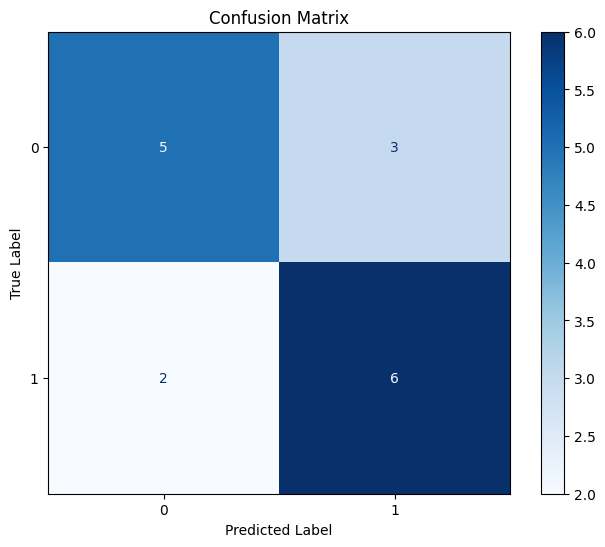

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Predict the classes on the test set
predicted_labels = model.predict(emg_after_test)
predicted_labels = np.round(predicted_labels).astype(int).flatten()

# Assuming output_test contains the true labels
true_labels = output_test.flatten()

# Compute the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Create a confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))  # Customize figure size
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## Dengan input matriks (36, 99, 3)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, GlobalAveragePooling1D
from tensorflow.keras.callbacks import Callback

class StopTrainingAtAccuracy(Callback):
    def __init__(self, target_accuracy):
        super(StopTrainingAtAccuracy, self).__init__()
        self.target_accuracy = target_accuracy

    def on_epoch_end(self, epoch, logs=None):
        accuracy = logs.get("accuracy")
        if accuracy >= self.target_accuracy:
            print(f"\nReached {self.target_accuracy*100:.2f}% accuracy, stopping training.")
            self.model.stop_training = True

model = Sequential([
    LSTM(64, input_shape=(emg_after.shape[1], emg_after.shape[2]), return_sequences=True),
    GlobalAveragePooling1D(),
    #LSTM(32),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (dummy labels for demonstration)
#y = np.random.randint(2, size=num_signals)  # Dummy binary labels

#model.fit(emg_after, output, epochs=100, batch_size=32)

target_accuracy = 0.95
stop_training_callback = StopTrainingAtAccuracy(target_accuracy)

# Train the model with the custom callback
model.fit(emg_after, output, epochs=400, batch_size=32, callbacks=[stop_training_callback])

Epoch 1/400
2/2 [==============================] - 3s 42ms/step - loss: 0.7348 - accuracy: 0.5000
Epoch 2/400
2/2 [==============================] - 0s 44ms/step - loss: 0.7231 - accuracy: 0.4167
Epoch 3/400
2/2 [==============================] - 0s 40ms/step - loss: 0.7138 - accuracy: 0.3889
Epoch 4/400
2/2 [==============================] - 0s 43ms/step - loss: 0.7078 - accuracy: 0.4444
Epoch 5/400
2/2 [==============================] - 0s 44ms/step - loss: 0.7013 - accuracy: 0.4444
Epoch 6/400
2/2 [==============================] - 0s 68ms/step - loss: 0.6952 - accuracy: 0.5556
Epoch 7/400
2/2 [==============================] - 0s 49ms/step - loss: 0.6922 - accuracy: 0.5278
Epoch 8/400
2/2 [==============================] - 0s 40ms/step - loss: 0.6895 - accuracy: 0.5278
Epoch 9/400
2/2 [==============================] - 0s 51ms/step - loss: 0.6884 - accuracy: 0.5278
Epoch 10/400
2/2 [==============================] - 0s 38ms/step - loss: 0.6853 - accuracy: 0.5833
Epoch 11/400
2/2 [=

In [ ]:
loss, accuracy = model.evaluate(emg_after_test, output_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')

1/1 [==============================] - 1s 606ms/step - loss: 0.9681 - accuracy: 0.5000
Test Loss: 0.9681002497673035, Test Accuracy: 0.5


1/1 [==============================] - 1s 614ms/step


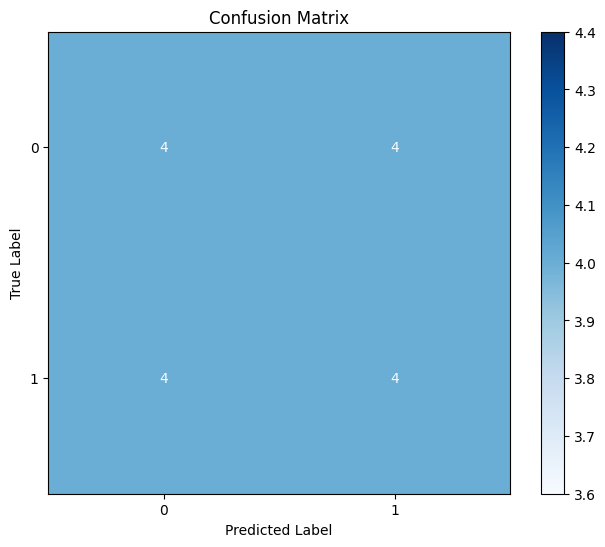

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Predict the classes on the test set
predicted_labels = model.predict(emg_after_test)
predicted_labels = np.round(predicted_labels).astype(int).flatten()

# Assuming output_test contains the true labels
true_labels = output_test.flatten()

# Compute the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Create a confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))  # Customize figure size
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
